In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# definition of a single cubit device
dev = qml.device("default.qubit", wires=1)

In [3]:
@qml.qnode(dev)
def parametric_circuit(theta):
    #Qubit is turned with an angle of theta wrt the y axis.
    qml.RY(theta, wires=0)
    
    #Returning the expected value at Pauli X axis
    return qml.expval(qml.PauliZ(0))

#Test the circuit with an arbitrary angle (phi/4).
print("Example: Expected value (theta = pi/4):", parametric_circuit(np.pi / 4))
print("\nCircuit Diagram:")
print(qml.draw(parametric_circuit)(np.pi / 4))

#What we expect to see is a superposition of the states |0> and |1>.
#Detector sometimes sees 1 and sometimes -1.
#Average value of the measurements is given when you run the code.

Example: Expected value (theta = pi/4): 0.7071067811865475

Circuit Diagram:
0: ──RY(0.79)─┤  <Z>


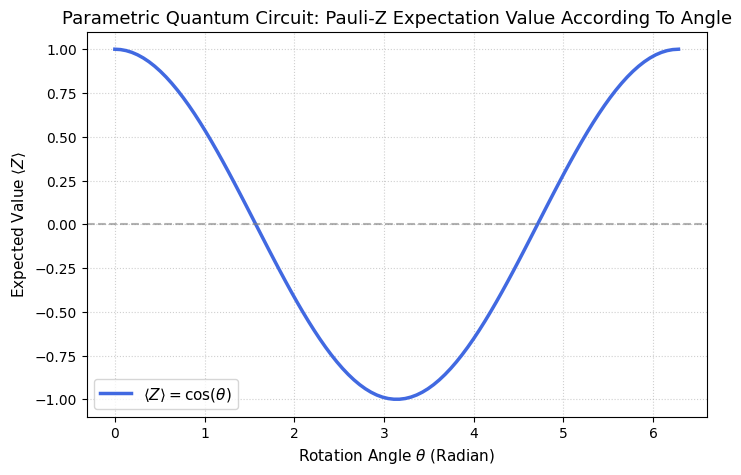

In [4]:
# Definition of 100 different angle value between 0 and 2*pi
angles = np.linspace(0, 2 * np.pi, 100)

# Testing the circuit wrt each angle between 0 and 2*pi, and adding all the expected values.
exp_values = [parametric_circuit(theta) for theta in angles]

# Draw the graph
plt.figure(figsize=(8, 5))
plt.plot(angles, exp_values, label=r"$\langle Z \rangle = \cos(\theta)$", color="royalblue", linewidth=2.5)

# Details of the graph
plt.title("Parametric Quantum Circuit: Pauli-Z Expectation Value According To Angle", fontsize=13)
plt.xlabel(r"Rotation Angle $\theta$ (Radian)", fontsize=11)
plt.ylabel(r"Expected Value $\langle Z \rangle$", fontsize=11)
plt.axhline(0, color="gray", linestyle="--", alpha=0.6)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.show()

#When theta is 0, outcome of the measurements is always 1. Because of that, graph begins at 1.
#When theta is nearly 3.14 radians,outcome of the measurements is always -1.
#When theta is 360 degrees, this corresponds to one complete rotation. Qubit is returned to the state at the begining.